In [ ]:
#  CV Lambda Sweep Overfitting Audit
# This is for CV models (the right panel in Exp3).
# It diagnoses:
# - whether eval PIER is monotone as budget increases
# - whether overfitting appears (`overfit_gap = eval - fit`)

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

tbl = Path('../results/tables').resolve()
art = Path('../results/artifacts').resolve()
art.mkdir(parents=True, exist_ok=True)
csv_path = tbl / 'exp3a2_cv_lambda_overfit.csv'
csv_path


PosixPath('/home/s242606/kernel_pier_project/results/tables/exp3a2_cv_lambda_overfit.csv')

## Run Exp3a2 (if CSV not generated yet)

```bash
cd ../
PYTHONPATH=. python3 experiments/exp3a2_cv_lambda_overfit_audit.py
```


In [2]:
df = pd.read_csv(csv_path)
df = df.sort_values(['target_model', 'budget']).reset_index(drop=True)
print('rows:', len(df), '| targets:', df['target_model'].nunique(), '| lambdas:', df['lambda'].nunique())
print('epsilon:', sorted(df['dose_epsilon'].unique()))
display(df.head())

summary = df.groupby(['target_model','target_group'], as_index=False).agg(
    convex_eval=('convex_pier_eval', 'mean'),
    best_eval=('kernel_pier_eval', 'min'),
    mean_overfit_gap=('overfit_gap', 'mean'),
    eval_rise_count=('eval_rise_count', 'max'),
)
summary.sort_values(['target_group','target_model'])


rows: 60 | targets: 5 | lambdas: 12
epsilon: [np.float64(0.1)]


,target_model,target_group,dose_epsilon,lambda,budget,convex_fit_distance,convex_pier_eval,convex_pier_fit,kernel_pier_eval,kernel_pier_fit,...,gamma,data_backend,model_backend,monotonic_tol,eval_delta_vs_prev,fit_delta_vs_prev,eval_increase_vs_prev,fit_increase_vs_prev,eval_rise_count,fit_rise_count
0,ConvNeXtTiny,Standard,0.1,3.00,0.333333,0.266576,0.043997,0.040201,0.028448,0.020749,...,0.086316,synthetic,fallback_tiny,0.0001,NaN,NaN,0,0,4,0
1,ConvNeXtTiny,Standard,0.1,1.00,1.000000,0.266576,0.043997,0.040201,0.022623,0.013961,...,0.086316,synthetic,fallback_tiny,0.0001,-0.005824,-0.006788,0,0,4,0
2,ConvNeXtTiny,Standard,0.1,0.30,3.333333,0.266576,0.043997,0.040201,0.016315,0.008184,...,0.086316,synthetic,fallback_tiny,0.0001,-0.006308,-0.005777,0,0,4,0
3,ConvNeXtTiny,Standard,0.1,0.10,10.000000,0.266576,0.043997,0.040201,0.011052,0.005086,...,0.086316,synthetic,fallback_tiny,0.0001,-0.005264,-0.003098,0,0,4,0
4,ConvNeXtTiny,Standard,0.1,0.03,33.333333,0.266576,0.043997,0.040201,0.005820,0.002471,...,0.086316,synthetic,fallback_tiny,0.0001,-0.005232,-0.002616,0,0,4,0


,target_model,target_group,convex_eval,best_eval,mean_overfit_gap,eval_rise_count
4,RobustResNet50,Robust,0.017519,0.000874,0.002018,0
0,ConvNeXtTiny,Standard,0.043997,0.001542,0.004078,4
1,EfficientNetB0,Standard,0.036389,0.006801,0.007145,3
2,ResNet18,Standard,0.021893,0.000363,0.001184,0
3,ResNet50,Standard,0.011913,0.000293,0.001212,0


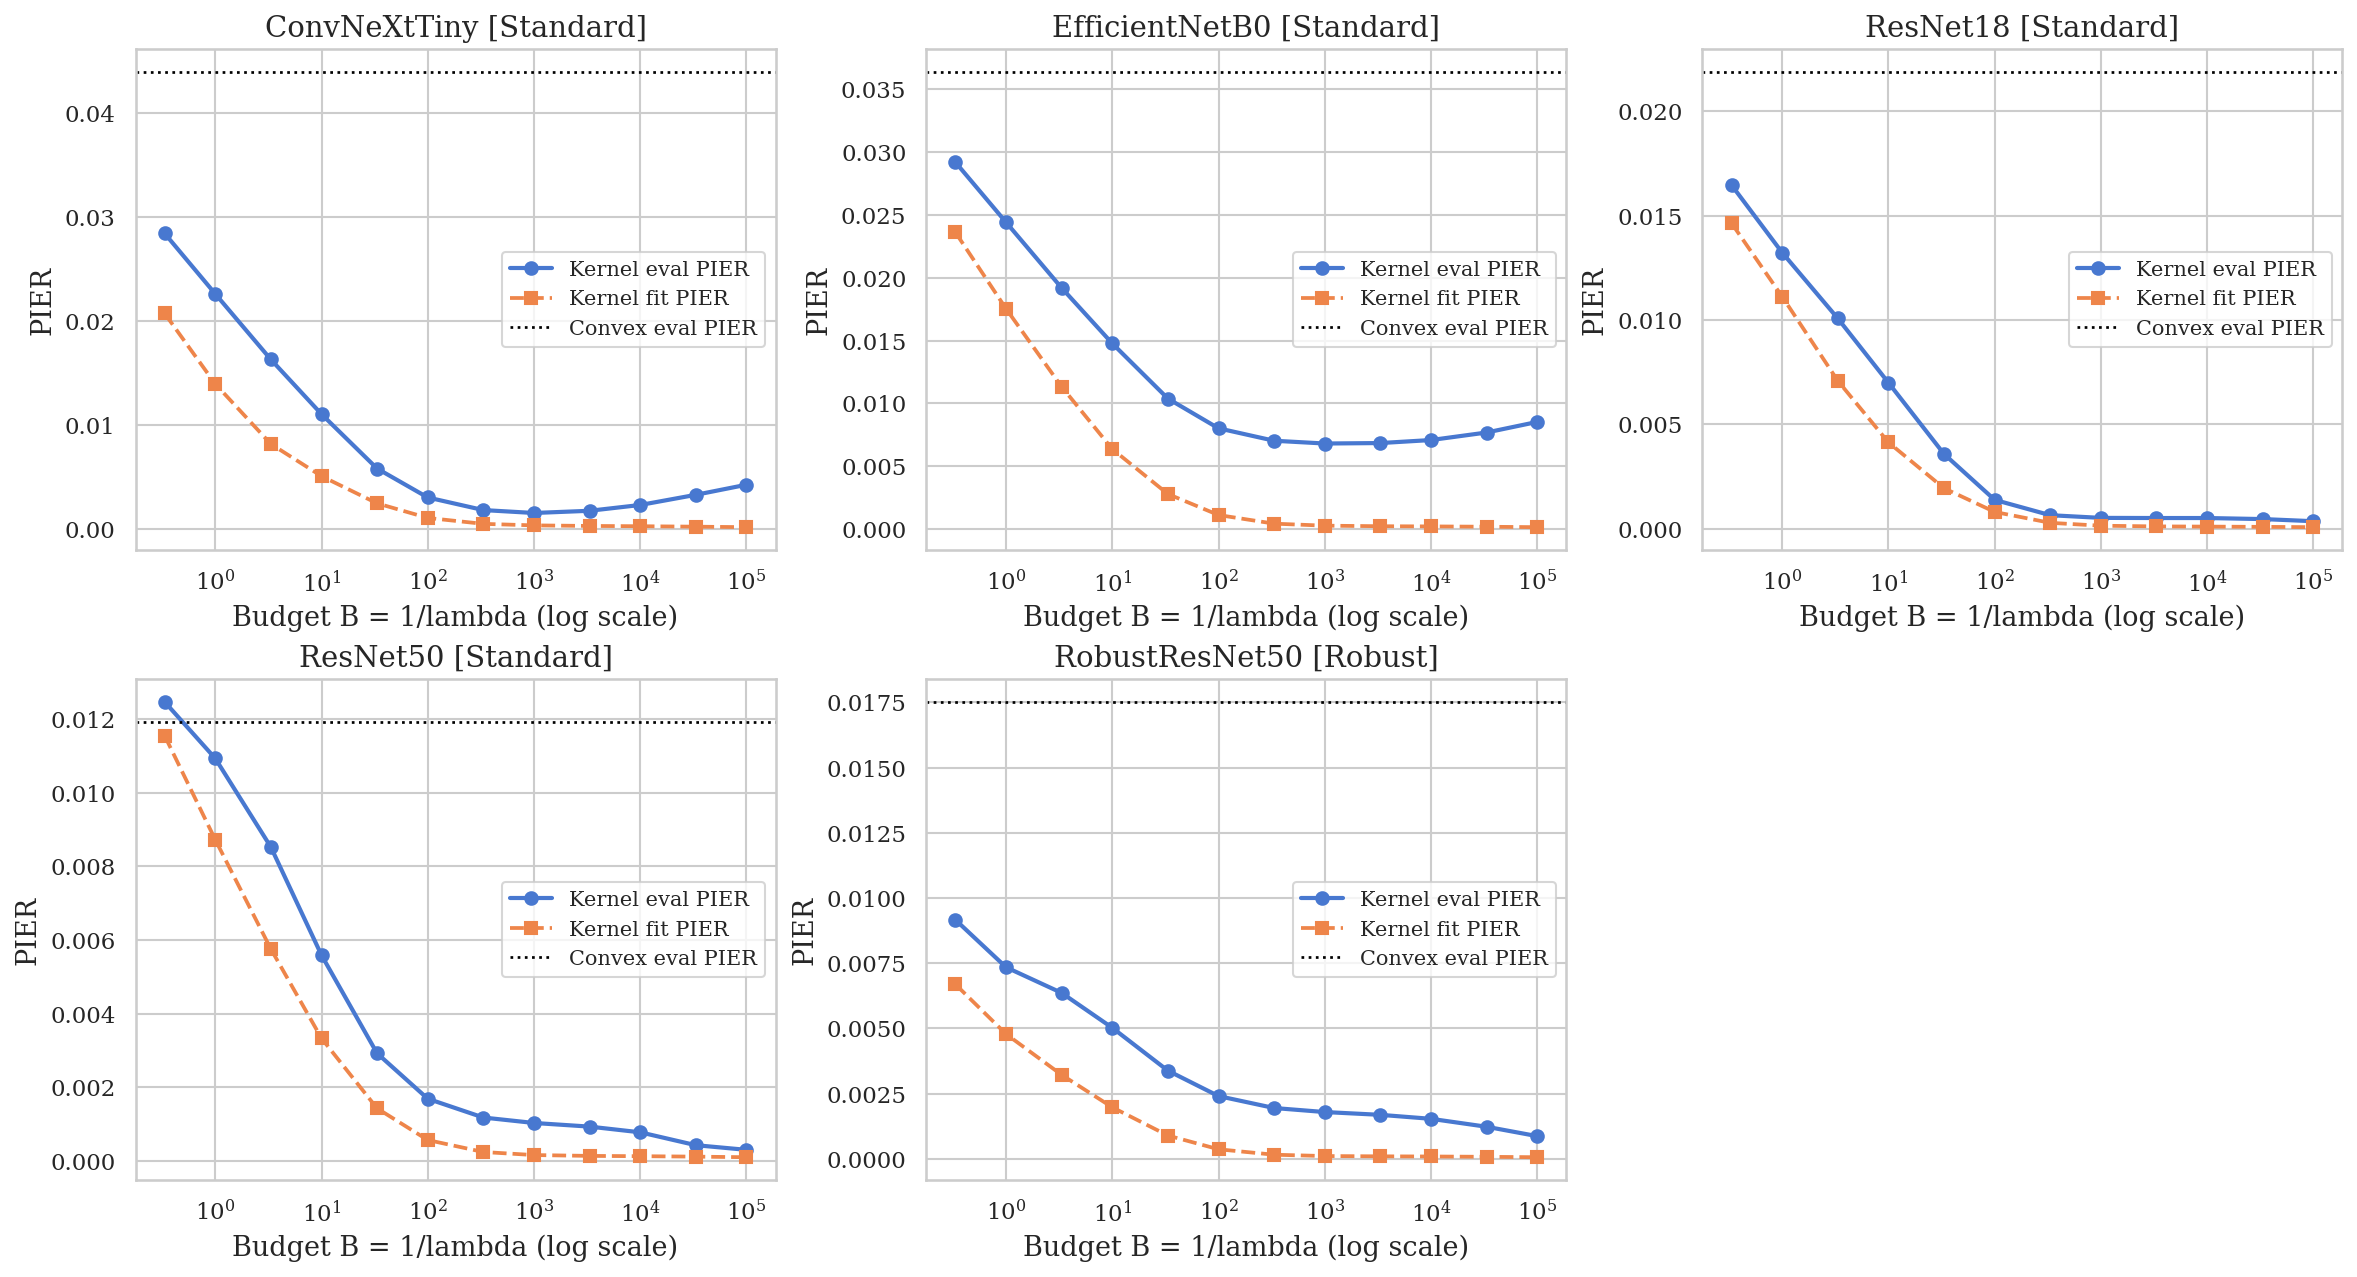

In [3]:
targets = list(df['target_model'].unique())
n = len(targets)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows), sharey=False, constrained_layout=True)
axes = np.array(axes).reshape(-1)

for ax, t in zip(axes, targets):
    sub = df[df['target_model'] == t].sort_values('budget')
    ax.plot(sub['budget'], sub['kernel_pier_eval'], marker='o', lw=2.0, label='Kernel eval PIER')
    ax.plot(sub['budget'], sub['kernel_pier_fit'], marker='s', lw=1.8, linestyle='--', label='Kernel fit PIER')
    ax.axhline(float(sub['convex_pier_eval'].iloc[0]), color='black', linestyle=':', lw=1.3, label='Convex eval PIER')
    ax.set_xscale('log')
    ax.set_xlabel('Budget B = 1/lambda (log scale)')
    ax.set_ylabel('PIER')
    g = sub['target_group'].iloc[0]
    ax.set_title(f'{t} [{g}]')
    ax.legend(loc='best')

for k in range(len(targets), len(axes)):
    axes[k].axis('off')

plt.savefig(art / 'exp3a2_budget_vs_fit_eval_pier_cv.pdf', bbox_inches='tight')
plt.show()


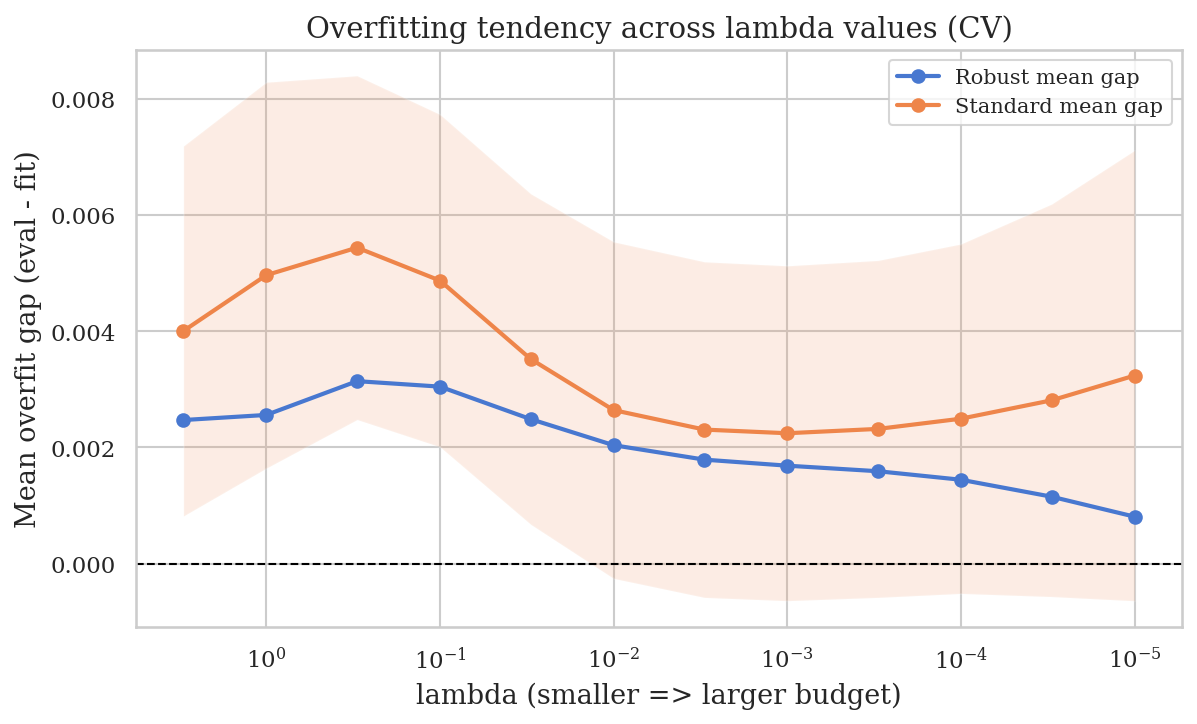

In [4]:
agg_gap = df.groupby(['lambda','target_group'], as_index=False).agg(
    gap_mu=('overfit_gap','mean'),
    gap_sd=('overfit_gap','std')
)
agg_gap = agg_gap.sort_values('lambda', ascending=False)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
for g, sub in agg_gap.groupby('target_group'):
    x = sub['lambda'].to_numpy()
    y = sub['gap_mu'].to_numpy()
    s = sub['gap_sd'].fillna(0.0).to_numpy()
    ax.plot(x, y, marker='o', linewidth=2.0, label=f'{g} mean gap')
    ax.fill_between(x, y - s, y + s, alpha=0.15)
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('lambda (smaller => larger budget)')
ax.set_ylabel('Mean overfit gap (eval - fit)')
ax.set_title('Overfitting tendency across lambda values (CV)')
ax.axhline(0.0, color='black', linestyle='--', lw=1)
ax.legend(loc='best')
plt.savefig(art / 'exp3a2_overfit_gap_by_lambda_cv.pdf', bbox_inches='tight')
plt.show()


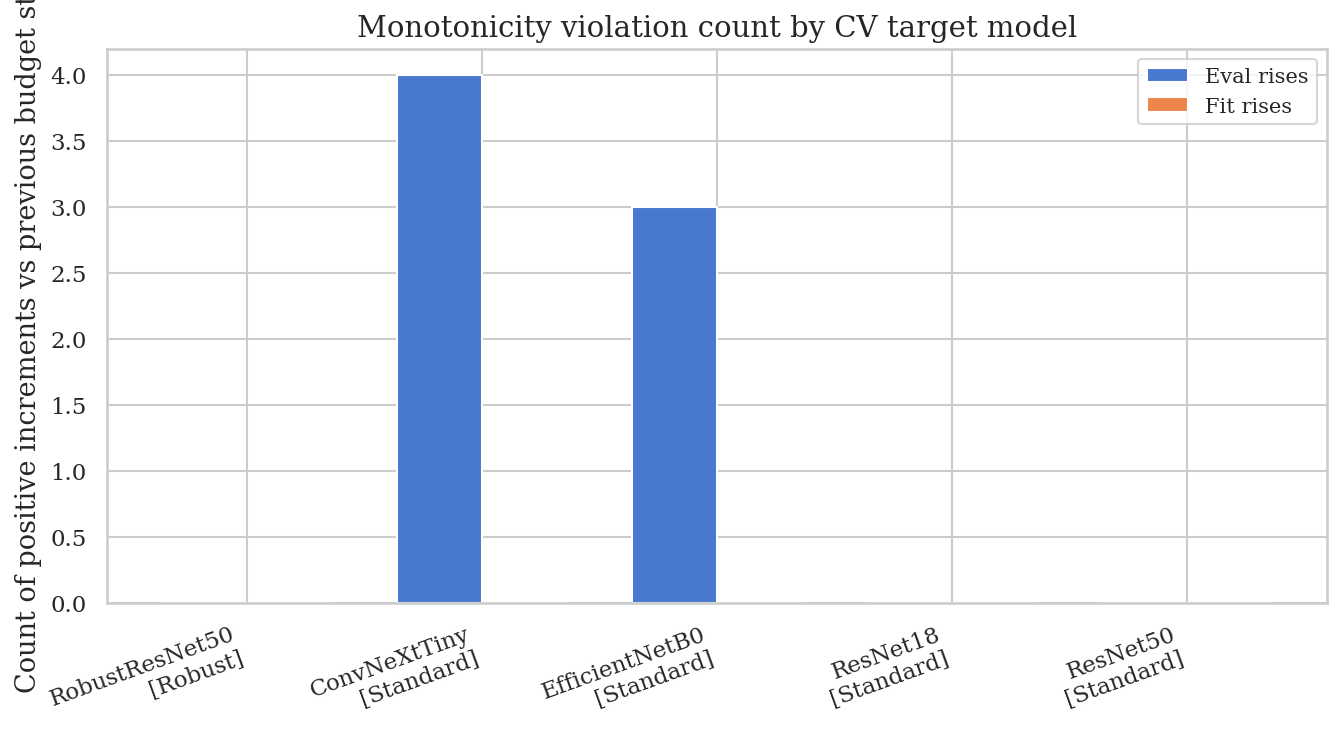

In [5]:
rise = df[['target_model','target_group','eval_rise_count','fit_rise_count']].drop_duplicates().sort_values(['target_group','target_model'])
fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(rise))
w = 0.36
ax.bar(x - w/2, rise['eval_rise_count'], width=w, label='Eval rises')
ax.bar(x + w/2, rise['fit_rise_count'], width=w, label='Fit rises')
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n[{g}]" for m,g in zip(rise['target_model'], rise['target_group'])], rotation=20, ha='right')
ax.set_ylabel('Count of positive increments vs previous budget step')
ax.set_title('Monotonicity violation count by CV target model')
ax.legend(loc='best')
plt.savefig(art / 'exp3a2_monotonic_violation_counts_cv.pdf', bbox_inches='tight')
plt.show()
